# Experiments

Этап 2: CV-бенчмарк моделей, эксперименты по обработке данных, PCA, тюнинг гиперпараметров, выбор финальной модели и интерпретируемость.

Метрика - `f1_macro`. Сплит тот же что в `02_baseline.ipynb` (70/15/15, `random_state=42`). Train+val используется для CV/тюнинга, test - только для финальной оценки.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from xgboost import XGBClassifier

from src.preprocessing import CLASS_LABELS, prepare_data
from src.modeling import (
    confusion,
    cross_validate_model,
    detailed_report,
    evaluate,
    get_candidate_models,
    make_pca_pipeline,
    make_pipeline,
    permutation_feature_importance,
    save_model,
    tune_model,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
RNG = 42

## 1. Данные

Train+val объединяем для CV. Test трогаем только в самом конце.

In [2]:
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(random_state=RNG)
X_dev = pd.concat([X_train, X_val]).reset_index(drop=True)
y_dev = pd.concat([y_train, y_val]).reset_index(drop=True)
print("dev:", X_dev.shape, "test:", X_test.shape)
print(y_dev.value_counts(normalize=True).round(3))

dev: (3031, 15) test: (535, 15)
PlanetClass
neptunian      0.348
terrestrial    0.342
gas_giant      0.310
Name: proportion, dtype: float64


## 2. CV-бенчмарк моделей

5-fold StratifiedKFold на dev. Дефолтные гиперпараметры.

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
le = LabelEncoder().fit(y_dev)

bench_rows = []
for name, model in get_candidate_models(RNG).items():
    yy = le.transform(y_dev) if name == "xgb" else y_dev
    cv = cross_validate(model, X_dev, yy, cv=skf, scoring=["f1_macro", "accuracy"], n_jobs=-1)
    bench_rows.append({
        "model": name,
        "mean_f1_macro": cv["test_f1_macro"].mean(),
        "std_f1_macro": cv["test_f1_macro"].std(),
        "mean_accuracy": cv["test_accuracy"].mean(),
    })
cv_table = pd.DataFrame(bench_rows).set_index("model").sort_values("mean_f1_macro", ascending=False).round(4)
cv_table

,mean_f1_macro,std_f1_macro,mean_accuracy
model,,,
random_forest,0.7209,0.0171,0.7159
xgb,0.7185,0.0188,0.7130
svm,0.7119,0.0108,0.7057
knn,0.7094,0.0150,0.7017
hist_gb,0.7055,0.0256,0.6988
logreg,0.6719,0.0162,0.6645


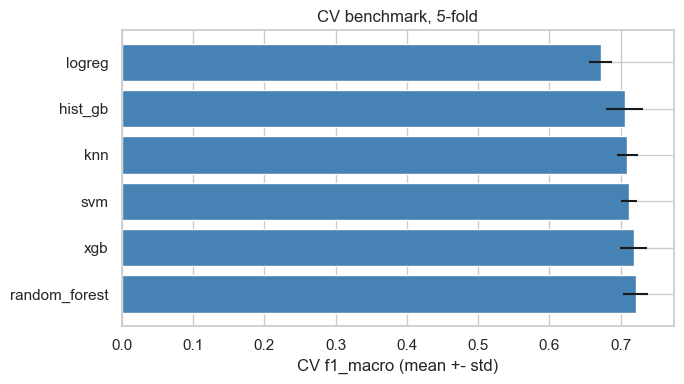

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(cv_table.index, cv_table["mean_f1_macro"], xerr=cv_table["std_f1_macro"], color="steelblue")
ax.set_xlabel("CV f1_macro (mean +- std)")
ax.set_title("CV benchmark, 5-fold")
plt.tight_layout()
plt.show()

## 3. Эксперименты по обработке данных

Гипотезы проверяем на RandomForest (300 деревьев), CV `f1_macro`.

- **Imputer**: KNN должен давать выгоду относительно median, тк часть фич (металличность, эксцентриситет) сильно пропущены.
- **Outliers**: IQR с k=3 мягче клипа по 99.5-квантилю и должен сохранять больше сигнала.

In [5]:
imputer_rows = []
for imp in ["median", "knn"]:
    model = make_pipeline(
        RandomForestClassifier(n_estimators=300, random_state=RNG, n_jobs=-1),
        numeric_imputer=imp,
    )
    res = cross_validate_model(model, X_dev, y_dev, cv=5, random_state=RNG)
    imputer_rows.append({"imputer": imp, **res})

outlier_rows = []
for strat in ["quantile", "iqr"]:
    Xtr, Xv, _, ytr, yv, _ = prepare_data(random_state=RNG, outlier_strategy=strat)
    Xd = pd.concat([Xtr, Xv]).reset_index(drop=True)
    yd = pd.concat([ytr, yv]).reset_index(drop=True)
    res = cross_validate_model(
        make_pipeline(RandomForestClassifier(n_estimators=300, random_state=RNG, n_jobs=-1)),
        Xd, yd, cv=5, random_state=RNG,
    )
    outlier_rows.append({"outlier": strat, **res})

print("imputer:")
print(pd.DataFrame(imputer_rows).set_index("imputer").round(4))
print()
print("outlier:")
print(pd.DataFrame(outlier_rows).set_index("outlier").round(4))

imputer:
         mean_f1_macro  std_f1_macro  mean_accuracy  std_accuracy
imputer                                                          
median          0.7209        0.0171         0.7159        0.0178
knn             0.7148        0.0143         0.7093        0.0142

outlier:
          mean_f1_macro  std_f1_macro  mean_accuracy  std_accuracy
outlier                                                           
quantile         0.7209        0.0171         0.7159        0.0178
iqr              0.7207        0.0181         0.7156        0.0187


**Вывод:** обе гипотезы не подтвердились.
- Median (0.7209) даже чуть лучше KNN (0.7148) - медианной импутации хватает, RandomForest неплохо переваривает оставшиеся пропуски.
- IQR (0.7207) и quantile (0.7209) практически совпадают - крайние значения после клипа уже не влияют на дерево.

Оставляем дефолтные `median` + `quantile`.

## 4. PCA

Среди фич есть скоррелированные (`PeriodDays` ↔ `LogPeriodDays`, `SemiMajorAxisAU` ↔ `LogSemiMajorAxisAU`). Смотрим, можно ли сжать.

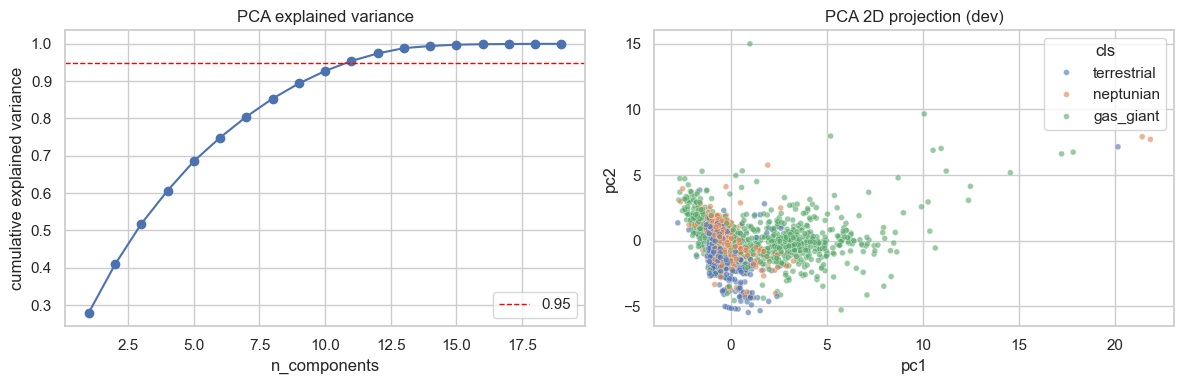

In [6]:
pre = make_pipeline(LogisticRegression(max_iter=1)).named_steps["preprocessor"]
X_dev_enc = pre.fit_transform(X_dev, y_dev)
explained = np.cumsum(PCA(random_state=RNG).fit(X_dev_enc).explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(explained) + 1), explained, marker="o")
axes[0].axhline(0.95, ls="--", color="red", lw=1, label="0.95")
axes[0].set_xlabel("n_components")
axes[0].set_ylabel("cumulative explained variance")
axes[0].set_title("PCA explained variance")
axes[0].legend()

pc = PCA(n_components=2, random_state=RNG).fit_transform(X_dev_enc)
proj = pd.DataFrame(pc, columns=["pc1", "pc2"]).assign(cls=y_dev.values)
sns.scatterplot(data=proj, x="pc1", y="pc2", hue="cls", hue_order=CLASS_LABELS, alpha=0.6, s=18, ax=axes[1])
axes[1].set_title("PCA 2D projection (dev)")
plt.tight_layout()
plt.show()

In [7]:
pca_rows = []
estimators = {
    "logreg": LogisticRegression(max_iter=1000, random_state=RNG),
    "svm": SVC(kernel="rbf", random_state=RNG),
    "random_forest": RandomForestClassifier(n_estimators=300, random_state=RNG, n_jobs=-1),
}
for name, est in estimators.items():
    base = cross_validate_model(make_pipeline(est), X_dev, y_dev, cv=5, random_state=RNG)
    pca_rows.append({"model": name, "n_components": "all", "mean_f1_macro": base["mean_f1_macro"]})
    for k in [2, 4, 6, 8, 10]:
        res = cross_validate_model(make_pca_pipeline(est, n_components=k), X_dev, y_dev, cv=5, random_state=RNG)
        pca_rows.append({"model": name, "n_components": k, "mean_f1_macro": res["mean_f1_macro"]})

pca_df = pd.DataFrame(pca_rows)
pca_df.pivot(index="n_components", columns="model", values="mean_f1_macro").round(4)

model,logreg,random_forest,svm
n_components,,,
2,0.5512,0.6148,0.6384
4,0.5782,0.6792,0.6951
6,0.6130,0.6999,0.6977
8,0.6376,0.7002,0.7002
10,0.6643,0.7094,0.7036
all,0.6719,0.7209,0.7119


**Вывод:** для покрытия 95% дисперсии нужно ~10 компонент из 14, и при любом `n_components` PCA только ухудшает CV `f1_macro` для всех трёх моделей (для RF падение с 0.721 при `all` до 0.679 при `n=4`). Логарифмические фичи и `EquilibriumProxy` несут полезный сигнал, который PCA размывает. В финальную модель PCA не берём.

## 5. Тюнинг гиперпараметров

Топ-3 модели по CV-бенчмарку: RandomForest, HistGradientBoosting, SVM. Tree-модели тюним `RandomizedSearchCV`, SVM - `GridSearchCV`.

In [8]:
rf_grid = {
    "estimator__n_estimators": [200, 400, 600, 800],
    "estimator__max_depth": [None, 6, 10, 16],
    "estimator__min_samples_split": [2, 4, 8],
    "estimator__min_samples_leaf": [1, 2, 4],
    "estimator__max_features": ["sqrt", "log2", 0.5],
}
rf_best, rf_params, rf_score = tune_model(
    make_pipeline(RandomForestClassifier(random_state=RNG, n_jobs=-1)),
    rf_grid, X_dev, y_dev, cv=5, search="random", n_iter=25, random_state=RNG,
)
print("RF:", round(rf_score, 4), rf_params)

/Users/georgepust/Desktop/university/3/ml/final_project/hseml-group-project-vivatttt/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/georgepust/Desktop/university/3/ml/final_project/hseml-group-project-vivatttt/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/georgepust/Desktop/university/3/ml/final_project/hseml-group-project-vivatttt/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Paral

RF: 0.7382 {'estimator__n_estimators': 400, 'estimator__min_samples_split': 2, 'estimator__min_samples_leaf': 1, 'estimator__max_features': 'sqrt', 'estimator__max_depth': 16}


In [9]:
hgb_grid = {
    "estimator__max_iter": [200, 400, 600],
    "estimator__learning_rate": [0.03, 0.05, 0.1, 0.2],
    "estimator__max_depth": [None, 4, 6, 10],
    "estimator__max_leaf_nodes": [15, 31, 63],
    "estimator__min_samples_leaf": [10, 20, 40],
    "estimator__l2_regularization": [0.0, 0.1, 1.0],
}
hgb_best, hgb_params, hgb_score = tune_model(
    make_pipeline(HistGradientBoostingClassifier(random_state=RNG)),
    hgb_grid, X_dev, y_dev, cv=5, search="random", n_iter=25, random_state=RNG,
)
print("HGB:", round(hgb_score, 4), hgb_params)

HGB: 0.7333 {'estimator__min_samples_leaf': 10, 'estimator__max_leaf_nodes': 31, 'estimator__max_iter': 200, 'estimator__max_depth': 6, 'estimator__learning_rate': 0.05, 'estimator__l2_regularization': 1.0}


In [10]:
svm_grid = {
    "estimator__C": [0.5, 1.0, 2.0, 4.0],
    "estimator__gamma": ["scale", 0.1, 0.5],
    "estimator__kernel": ["rbf"],
}
svm_best, svm_params, svm_score = tune_model(
    make_pipeline(SVC(random_state=RNG)),
    svm_grid, X_dev, y_dev, cv=5, search="grid", random_state=RNG,
)
print("SVM:", round(svm_score, 4), svm_params)

SVM: 0.7182 {'estimator__C': 2.0, 'estimator__gamma': 0.5, 'estimator__kernel': 'rbf'}


## 6. Сводная таблица экспериментов

In [11]:
summary = (
    [{"experiment": f"benchmark_{n}", "cv_f1_macro": r["mean_f1_macro"]} for n, r in cv_table.iterrows()]
    + [{"experiment": f"imputer_{r['imputer']}", "cv_f1_macro": r["mean_f1_macro"]} for r in imputer_rows]
    + [{"experiment": f"outlier_{r['outlier']}", "cv_f1_macro": r["mean_f1_macro"]} for r in outlier_rows]
    + [{"experiment": f"pca_{r['model']}_n={r['n_components']}", "cv_f1_macro": r["mean_f1_macro"]} for r in pca_rows]
    + [
        {"experiment": "tuned_random_forest", "cv_f1_macro": rf_score},
        {"experiment": "tuned_hist_gb", "cv_f1_macro": hgb_score},
        {"experiment": "tuned_svm", "cv_f1_macro": svm_score},
    ]
)
summary_df = pd.DataFrame(summary).sort_values("cv_f1_macro", ascending=False).reset_index(drop=True).round(4)
(ROOT / "report" / "experiments.csv").write_text(summary_df.to_csv(index=False))
summary_df

,experiment,cv_f1_macro
0,tuned_random_forest,0.7382
1,tuned_hist_gb,0.7333
2,benchmark_random_forest,0.7209
3,outlier_quantile,0.7209
4,pca_random_forest_n=all,0.7209
5,imputer_median,0.7209
6,outlier_iqr,0.7207
7,benchmark_xgb,0.7185
8,tuned_svm,0.7182
9,imputer_knn,0.7148


## 7. Финальная модель

Лучшая по CV - переобучаем на dev (train+val), оцениваем один раз на test.

final: random_forest | CV f1_macro = 0.7382
              precision    recall  f1-score   support

   gas_giant     0.8698    0.8855    0.8776       166
   neptunian     0.6760    0.6505    0.6630       186
 terrestrial     0.6791    0.6940    0.6865       183

    accuracy                         0.7383       535
   macro avg     0.7416    0.7434    0.7424       535
weighted avg     0.7372    0.7383    0.7376       535

test: {'accuracy': 0.7383, 'f1_macro': 0.7424, 'f1_weighted': 0.7376}


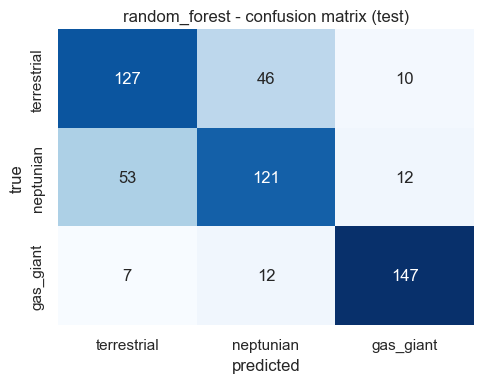

saved: /Users/georgepust/Desktop/university/3/ml/final_project/hseml-group-project-vivatttt/models/final_model.joblib


In [12]:
candidates = {"random_forest": (rf_best, rf_score), "hist_gb": (hgb_best, hgb_score), "svm": (svm_best, svm_score)}
final_name = max(candidates, key=lambda k: candidates[k][1])
final_model = candidates[final_name][0]
print(f"final: {final_name} | CV f1_macro = {candidates[final_name][1]:.4f}")

print(detailed_report(final_model, X_test, y_test))
print("test:", {k: round(v, 4) for k, v in evaluate(final_model, X_test, y_test).items()})

cm = confusion(final_model, X_test, y_test, labels=CLASS_LABELS)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax, cbar=False)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title(f"{final_name} - confusion matrix (test)")
plt.tight_layout()
plt.show()

print("saved:", save_model(final_model, "final_model.joblib"))

## 8. Интерпретируемость

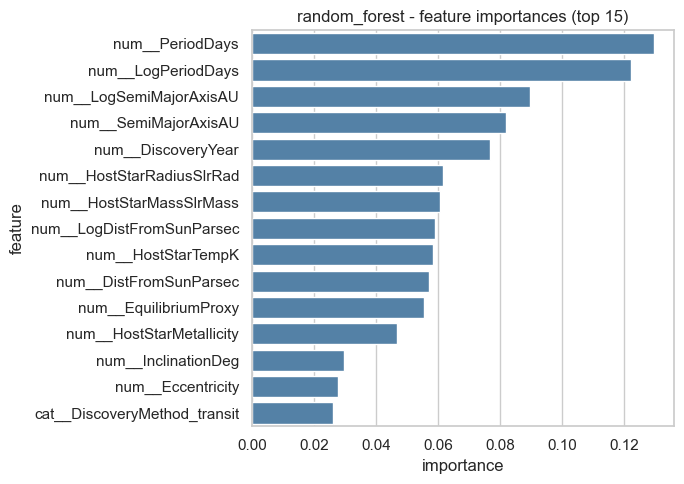

,feature,importance
0,num__PeriodDays,0.129502
1,num__LogPeriodDays,0.122020
2,num__LogSemiMajorAxisAU,0.089711
3,num__SemiMajorAxisAU,0.081696
4,num__DiscoveryYear,0.076707
5,num__HostStarRadiusSlrRad,0.061627
6,num__HostStarMassSlrMass,0.060461
7,num__LogDistFromSunParsec,0.059053
8,num__HostStarTempK,0.058430
9,num__DistFromSunParsec,0.057146


In [13]:
est = final_model.named_steps["estimator"]
fnames = final_model.named_steps["preprocessor"].get_feature_names_out()
fi = pd.DataFrame({"feature": fnames, "importance": est.feature_importances_}) \
    .sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=fi.head(15), x="importance", y="feature", color="steelblue", ax=ax)
ax.set_title(f"{final_name} - feature importances (top 15)")
plt.tight_layout()
plt.show()
fi.head(15)

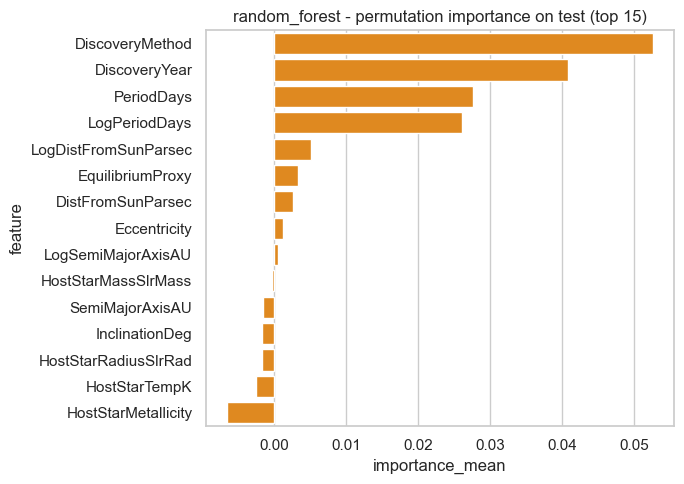

,feature,importance_mean,importance_std
0,DiscoveryMethod,0.0525,0.0091
1,DiscoveryYear,0.0408,0.0121
2,PeriodDays,0.0277,0.0084
3,LogPeriodDays,0.0261,0.0125
4,LogDistFromSunParsec,0.0052,0.0065
5,EquilibriumProxy,0.0033,0.0042
6,DistFromSunParsec,0.0027,0.0083
7,Eccentricity,0.0013,0.0031
8,LogSemiMajorAxisAU,0.0006,0.0037
9,HostStarMassSlrMass,-0.0002,0.0068


In [14]:
perm = permutation_feature_importance(final_model, X_test, y_test, n_repeats=10, random_state=RNG)
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=perm.head(15), x="importance_mean", y="feature", color="darkorange", ax=ax)
ax.set_title(f"{final_name} - permutation importance on test (top 15)")
plt.tight_layout()
plt.show()
perm.round(4)

In [15]:
lr = make_pipeline(LogisticRegression(max_iter=1000, random_state=RNG)).fit(X_dev, y_dev)
coefs = pd.DataFrame(
    lr.named_steps["estimator"].coef_,
    columns=lr.named_steps["preprocessor"].get_feature_names_out(),
    index=lr.named_steps["estimator"].classes_,
).T
coefs.round(3)

,gas_giant,neptunian,terrestrial
num__PeriodDays,0.207,-0.535,0.328
num__SemiMajorAxisAU,-0.772,0.688,0.084
num__Eccentricity,0.091,0.018,-0.109
num__InclinationDeg,0.010,0.051,-0.061
num__HostStarMassSlrMass,0.200,-0.116,-0.084
num__HostStarRadiusSlrRad,0.828,0.055,-0.883
num__HostStarMetallicity,0.252,-0.020,-0.232
num__HostStarTempK,-0.065,0.038,0.026
num__DistFromSunParsec,-0.005,0.064,-0.059
num__DiscoveryYear,-0.109,-0.093,0.203
